# Weighted Random Sampling

Let us verify that `WeightedRandomSampler` correctly balances the class distribution in our training batches. Without sampling, the batches would reflect the natural imbalanced distribution of the dataset, potentially leading to skewed samples during training.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
from pathlib import Path

project_root = Path("../..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from jute_disease.data.datamodule import DataModule
from tqdm import tqdm

from jute_disease.utils.constants import DEFAULT_SEED
from jute_disease.utils.logger import get_logger
from jute_disease.utils.seed import seed_everything

logger = get_logger(__name__)
seed_everything(DEFAULT_SEED)

Seed set to 42


2026-03-07 16:47:00,084 - jute_disease.utils.seed - INFO - Random seed set to: 42


Let us instantiate two `DataModule` instances: one that does not use a weighted sampler and one that does.

In [5]:
dm_natural = DataModule(use_weighted_sampler=False)
dm_natural.prepare_data()
dm_natural.setup()

dm_weighted = DataModule(use_weighted_sampler=True)
dm_weighted.prepare_data()
dm_weighted.setup()

logger.info(f"Classes: {dm_weighted.classes}")

2026-03-07 16:47:29,915 - jute_disease.data.utils - INFO - Split directory /home/qu1r0ra/Documents/GitHub/jute-disease-detection/data/ml_split already exists. Skipping split.
2026-03-07 16:47:29,941 - jute_disease.data.utils - INFO - Split directory /home/qu1r0ra/Documents/GitHub/jute-disease-detection/data/ml_split already exists. Skipping split.
2026-03-07 16:47:29,960 - __main__ - INFO - Classes: ['Cercospora Leaf Spot', 'Dieback', 'General Damage', 'Healthy', 'Mosaic', 'Stem Rot']


In [6]:
def collect_labels(dm, num_batches=50):
    loader = dm.train_dataloader()
    all_labels = []
    logger.info(f"Collecting {num_batches} batches...")
    for i, batch in tqdm(enumerate(loader), total=num_batches):
        if i >= num_batches:
            break
        _, labels = batch
        all_labels.extend(labels.tolist())
    return all_labels


logger.info("Collecting natural samples...")
natural_labels = collect_labels(dm_natural)

logger.info("Collecting weighted samples...")
weighted_labels = collect_labels(dm_weighted)

2026-03-07 16:48:56,719 - __main__ - INFO - Collecting natural samples...
2026-03-07 16:48:56,721 - __main__ - INFO - Checking 50 batches...


/home/qu1r0ra/Documents/GitHub/jute-disease-detection/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 50/50 [00:55<00:00,  1.12s/it]

2026-03-07 16:49:52,723 - __main__ - INFO - Collecting weighted samples...
2026-03-07 16:49:52,725 - __main__ - INFO - Checking 50 batches...



100%|██████████| 50/50 [00:43<00:00,  1.16it/s]


Let us visualize and compare the two distributions.

2026-03-07 16:53:19,314 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-07 16:53:19,324 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-07 16:53:19,374 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-07 16:53:19,384 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


/tmp/ipykernel_803942/2007270185.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(dm_natural.classes, rotation=45, ha="right")
/tmp/ipykernel_803942/2007270185.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(dm_weighted.classes, rotation=45, ha="right")


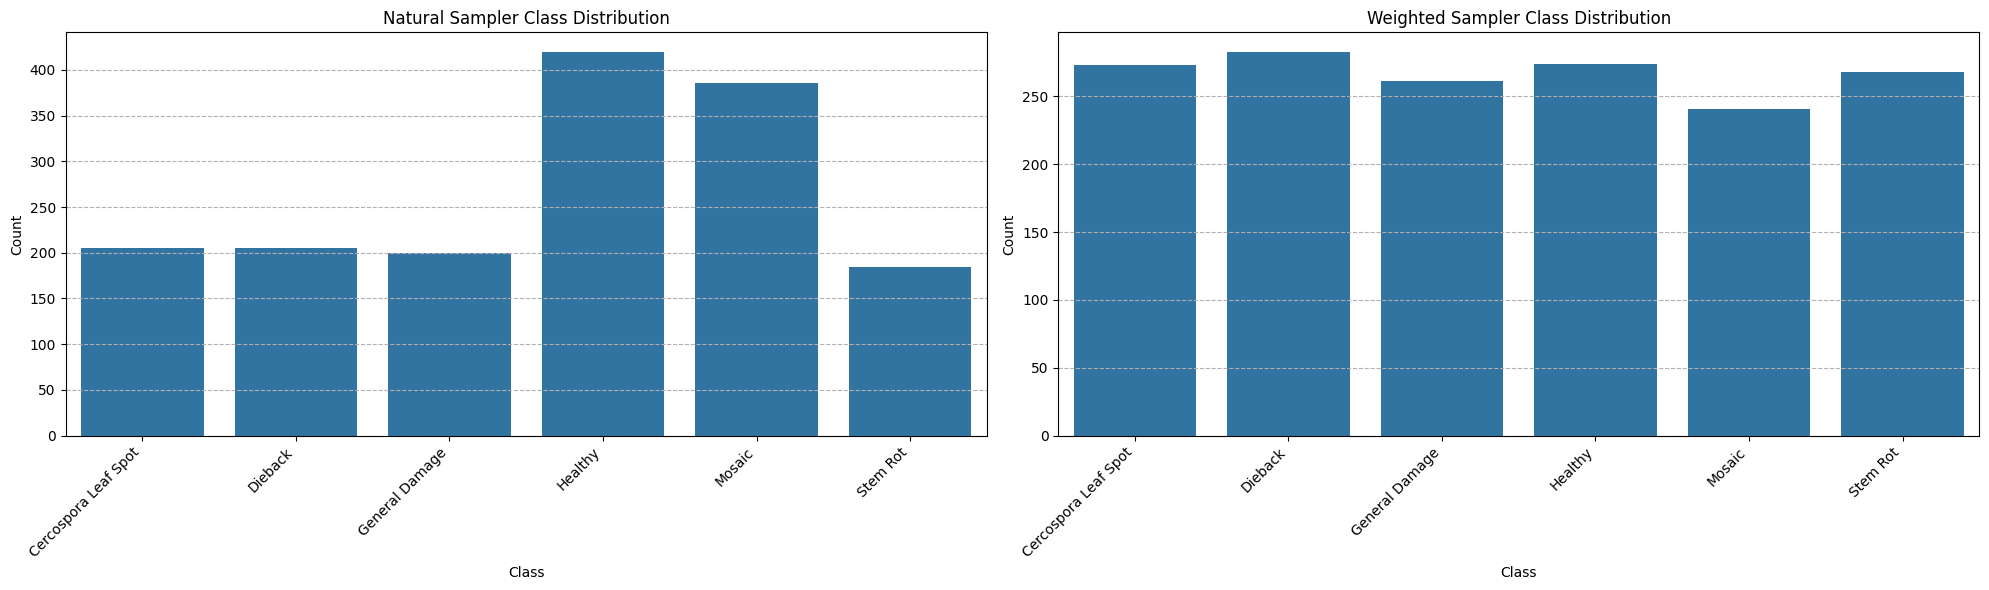

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.countplot(x=natural_labels, ax=axes[0])
axes[0].set_title("Natural Sampler Class Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(dm_natural.classes, rotation=45, ha="right")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

sns.countplot(x=weighted_labels, ax=axes[1])
axes[1].set_title("Weighted Sampler Class Distribution")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(dm_weighted.classes, rotation=45, ha="right")
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

From the histograms above, we can see that the weighted random sampler is more appropriate than the natural sampler for our case as it results in a more balanced distribution of classes from a sample.